<div style="
margin-bottom:2.2em;
">

<div style="
color:#b07a4f;
font-size:1.55em;
font-weight:600;
margin-bottom:0.35em;
">

Plausible Actionable Counterfactual Recourse with Action Paths (PACR-AP)

</div>

<div style="
opacity:0.78;
line-height:1.9;
font-size:1.02em;
">


Ceci constitue un bonus à notre projet et non le centre de notre analyse. Nous y présentons une méthode de recourse contrefactuel qui prend en compte les coûts d’action, et nous l’appliquons à notre dataset pour illustrer les compromis entre différentes notions de fairness.

</div>

</div>

<hr style="
margin:2.6em 0 2.4em 0;
border:none;
border-top:1px solid rgba(255,255,255,0.10);
">

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">


<div style="
margin-top:1.5em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Convention utilisée pour les métriques de fairness</b>

<p style="margin-top:0.9em;">
Les écarts sont calculés dans le sens :
</p>

<div style="
text-align:center;
font-size:1.05em;
margin:1.2em 0 1.2em 0;
">

$$
\Delta_M
=
M_{\text{jeunes}}
-
M_{\text{adultes}}
$$

</div>

<p>
Un écart positif indique donc une valeur plus élevée pour le groupe défavorisé,
tandis qu’un écart négatif indique une valeur plus élevée pour le groupe favorisé.
</p>

</div>

<hr style="
margin:3em 0;
border:none;
border-top:1px solid rgba(255,255,255,0.10);
">

<div style="
margin-bottom:2em;
">

<div style="
font-size:1.45em;
font-weight:600;
margin-bottom:0.25em;
">

1. La méthode en bref

</div>

</div>

<div style="
margin:1.2em 0 1.8em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

<b>Question étudiée</b>

Pour un emprunteur refusé par le modèle de scoring crédit,
existe-t-il une <b>séquence d’actions plausibles</b> permettant de faire basculer la décision ?

Et cette possibilité de recours est-elle équitable entre groupes d’âge ?

</div>

<p style="line-height:1.95;">
Notre méthode,
<b>Plausible Actionable Counterfactual Recourse with Action Paths (PACR-AP)</b>,
part du contrefactuel de Wachter (2017) —
<i>« trouver un point qui change la décision »</i> —
mais l’adapte à plusieurs contraintes spécifiques au crédit.
</p>

<br>

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

<b>1. Toutes les actions ne sont pas éligibles</b>

<p style="margin-top:0.8em;">
On ne peut pas demander à un emprunteur de modifier son âge ou son sexe.
Il faut donc définir explicitement quelles variables sont modifiables,
dans quelle direction,
et sous quelles contraintes.
</p>

<p>
Cette idée provient du <b>schéma d’actionnabilité</b>
de <b>Ustun et al. (2019)</b>.
</p>

</div>

<div style="
margin:1.6em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

<b>2. Un profil final plausible ne suffit pas</b>

<p style="margin-top:0.8em;">
Un client ne modifie pas toutes ses caractéristiques instantanément.
Il passe par une <b>suite d’actions élémentaires</b>,
et chaque étape intermédiaire doit elle aussi rester crédible.
</p>

<p>
Nous empruntons donc à <b>FACE</b> (Poyiadzi et al., 2020)
l’idée de raisonner en <b>chemins d’actions plausibles</b>,
avec vérification de plausibilité
à chaque transition et pas uniquement au point final.
</p>

</div>

<div style="
margin:1.6em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

<b>3. Un seul chemin serait trop rigide</b>

<p style="margin-top:0.8em;">
Deux individus peuvent avoir des contraintes très différentes :
certains peuvent réduire leur montant emprunté,
d’autres peuvent uniquement allonger leur durée de remboursement.
</p>

<p>
Nous reprenons donc l’idée de <b>DiCE</b>
(Mothilal et al., 2020) :
produire plusieurs chemins plausibles et diversifiés,
afin de laisser un véritable choix à l’utilisateur.
</p>

</div>

<div style="
margin-top:1.8em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Important</b>

La méthode répond à la question :

<div style="
text-align:center;
margin:1.1em 0;
font-style:italic;
">

« comment faire basculer la décision du modèle ? »

</div>

et non à :

<div style="
text-align:center;
margin:1.1em 0 0.3em 0;
font-style:italic;
">

« comment réduire le véritable risque de défaut ? »

</div>

<p style="margin-top:1em;">
Les chemins produits sont donc
<b>prédictifs</b> et non <b>causaux</b>.
Obtenir des recommandations causalement valides nécessiterait
un modèle causal structurel complet
(Karimi et al., 2021),
hors du périmètre de ce travail.
</p>

</div>

<br>

<div style="
margin:1.8em 0 1.2em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.95;
">

<b>Récapitulatif des briques méthodologiques</b>

</div>

<table style="
width:100%;
border-collapse:collapse;
font-size:0.98em;
margin:1em 0 2em 0;
">

<thead>

<tr style="
border-bottom:1px solid rgba(255,255,255,0.12);
">

<th style="padding:0.7em;text-align:center;">
#
</th>

<th style="padding:0.7em;text-align:left;">
Brique
</th>

<th style="padding:0.7em;text-align:left;">
Source
</th>

</tr>

</thead>

<tbody>

<tr style="border-bottom:1px solid rgba(255,255,255,0.06);">
<td style="padding:0.75em;text-align:center;">1</td>
<td style="padding:0.75em;">Contrefactuel basculant la décision</td>
<td style="padding:0.75em;">Wachter, Mittelstadt & Russell (2017)</td>
</tr>

<tr style="border-bottom:1px solid rgba(255,255,255,0.06);">
<td style="padding:0.75em;text-align:center;">2</td>
<td style="padding:0.75em;">Schéma d’actionnabilité (mutable / direction)</td>
<td style="padding:0.75em;">Ustun, Spangher & Liu (2019)</td>
</tr>

<tr style="border-bottom:1px solid rgba(255,255,255,0.06);">
<td style="padding:0.75em;text-align:center;">3</td>
<td style="padding:0.75em;">K chemins diversifiés</td>
<td style="padding:0.75em;">Mothilal, Sharma & Tan (2020) — <i>DiCE</i></td>
</tr>

<tr style="border-bottom:1px solid rgba(255,255,255,0.06);">
<td style="padding:0.75em;text-align:center;">4</td>
<td style="padding:0.75em;">Exploration discrète + plausibilité de trajectoire</td>
<td style="padding:0.75em;">Karimi et al. (2020) — <i>MACE</i> ; Poyiadzi et al. (2020) — <i>FACE</i></td>
</tr>

<tr>
<td style="padding:0.75em;text-align:center;">5</td>
<td style="padding:0.75em;">Plausibilité conjointe</td>
<td style="padding:0.75em;">Breunig et al. (2000) — <i>LOF</i></td>
</tr>

</tbody>

</table>

<div style="
margin:2em 0;
padding-left:1.1em;
border-left:3px solid #8d6cab;
line-height:1.95;
">

<b>Ce que PACR-AP ajoute en propre</b>

<ul style="margin-top:0.9em;">

<li>
seuil de décision <b>cost-optimal</b>

<div style="
text-align:center;
margin:0.8em 0;
">

$$
\tau^* = \frac{5}{6}\approx 0.833
$$

</div>

</li>

<li style="margin-top:0.55em;">
magnitudes d’actions apprises depuis les transitions
refusé → favorable observées dans les données 
</li>

<li style="margin-top:0.55em;">
plausibilité hybride :
distance locale NN + plausibilité conjointe LOF 
</li>

<li style="margin-top:0.55em;">
audit de <i>fairness of recourse</i>
par groupe d’âge :
équité du coût,
de la difficulté
et de la robustesse des chemins.
</li>

</ul>

</div>

<div style="
margin-top:1.8em;
padding-top:0.9em;
border-top:1px solid rgba(255,255,255,0.12);
font-size:1.01em;
line-height:1.95;
">

> **Détail formel** : voir [Annexe A — Méthode](Annexe_Méthode.ipynb)

> **Discussion littérature complète** : voir [Annexe B — Littérature](Annexe_Littérature.ipynb)

> **Mining des magnitudes** : voir [Annexe C — Mining](Annexe_Mining.ipynb)

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
from typing import Callable, Optional, Dict, List, Tuple, Any
from collections import Counter, deque
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, accuracy_score

<hr style="
margin:3em 0;
border:none;
border-top:1px solid rgba(255,255,255,0.10);
">

<div style="
margin-bottom:2em;
">

<div style="
font-size:1.45em;
font-weight:600;
margin-bottom:0.25em;
">

2. Overview du pipeline

</div>

</div>

<div style="
margin:1.3em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

<b>Deux niveaux d’analyse</b>

La méthode peut être lue à deux échelles :

<ul style="margin-top:0.8em;">

<li>
ce qui est produit <b>pour un emprunteur individuel</b> 
</li>

<li style="margin-top:0.45em;">
ce qui est évalué <b>au niveau global</b>
pour auditer l’équité des possibilités de recours.
</li>

</ul>

</div>

<br>

<div style="
margin:1.8em 0 1.2em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.95;
">

<b>Pipeline par individu</b>

</div>

<div style="
text-align:center;
margin:1.6em 0 2em 0;
">

<img
src="figures/pacr_ap_pipeline.png"
style="
max-width:100%;
border-radius:8px;
opacity:0.97;
"
/>

</div>

<p style="line-height:1.95;">
Pour chaque emprunteur refusé,
la méthode construit un graphe de
<b>chemins d’actions élémentaires</b>
à partir du profil initial.
</p>

<div style="
margin:1.5em 0;
padding:1em 1.15em;
background:rgba(255,255,255,0.03);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Exemples d’actions</b>

<ul style="margin-top:0.8em;">

<li>
réduire le montant demandé de 20 % 
</li>

<li style="margin-top:0.45em;">
améliorer le statut du compte courant d’un niveau 
</li>

<li style="margin-top:0.45em;">
augmenter l’apport personnel 
</li>

<li style="margin-top:0.45em;">
allonger la durée de remboursement.
</li>

</ul>

</div>

<p style="line-height:1.95;">
Toutes les transitions doivent respecter
le schéma d’actionnabilité :
les variables non modifiables sont bloquées,
et les directions autorisées sont imposées.
</p>

<p style="line-height:1.95;">
À chaque étape,
les profils intermédiaires jugés trop atypiques
ou irréalistes sont éliminés
par les filtres de plausibilité.
</p>

<div style="
margin:1.6em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

<b>Sélection finale des chemins</b>

Parmi tous les chemins plausibles
qui réussissent à faire basculer la décision,
la méthode conserve un ensemble de
<b>K chemins diversifiés</b>.

<p style="margin-top:0.9em;">
Chaque chemin cherche un compromis entre :
</p>

<ul style="margin-top:0.7em;">

<li>
coût des actions 
</li>

<li style="margin-top:0.45em;">
plausibilité du parcours 
</li>

<li style="margin-top:0.45em;">
robustesse du basculement.
</li>

</ul>

<p style="margin-top:0.9em;">
Les recommandations finales sont ensuite
traduites en langage métier compréhensible
par l’utilisateur.
</p>

</div>

<hr style="
margin:3em 0;
border:none;
border-top:1px solid rgba(255,255,255,0.10);
">

<div style="
margin:1.8em 0 1.2em 0;
padding-left:1.1em;
border-left:3px solid #8d6cab;
line-height:1.95;
">

<b>Audit fairness of recourse</b>

</div>

<div style="
text-align:center;
margin:1.6em 0 2em 0;
">

<img
src="figures/pacr_ap_audit.png"
style="
max-width:100%;
border-radius:8px;
opacity:0.97;
"
/>

</div>

<p style="line-height:1.95;">
Le pipeline précédent est ensuite rejoué
sur l’ensemble des individus refusés,
puis les résultats sont agrégés
par groupe sensible
(<b>jeunes</b> vs <b>adultes</b>).
</p>

<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

<b>Métriques étudiées</b>

Les principaux écarts analysés concernent :

<ul style="margin-top:0.8em;">

<li>
le <b>coverage</b> :
proportion d’individus pour lesquels un recours existe 
</li>

<li style="margin-top:0.45em;">
le <b>coût</b> des chemins proposés 
</li>

<li style="margin-top:0.45em;">
la <b>robustesse</b> des solutions obtenues.
</li>

</ul>

</div>

<div style="
margin-top:1.7em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Point important</b>

Le schéma d’actionnabilité
reste un choix normatif et politique :
ce qui est considéré comme
« raisonnablement modifiable »
dépend du contexte institutionnel.

<p style="margin-top:0.9em;">
Le verdict de fairness est donc
stress-testé sous plusieurs variantes plausibles
du schéma d’actionnabilité.
</p>

<p>
Le résultat n’est considéré robuste
que si les écarts observés
gardent le même signe
dans les différents scénarios.
</p>

</div>

<hr style="
margin:3em 0;
border:none;
border-top:1px solid rgba(255,255,255,0.10);
">

<div style="
font-size:1.45em;
font-weight:600;
margin-bottom:1.4em;
">

3. Setup expérimental

</div>

<p style="line-height:1.95;">
Les données sont chargées depuis <b>OpenML</b>,
puis une baseline de
<b>régression logistique cost-sensitive</b>
est entraînée.
</p>

<p style="line-height:1.95;">
Le notebook ne contient que l’orchestration expérimentale :
toute la mécanique de génération des chemins,
de filtrage de plausibilité
et d’audit est encapsulée dans le module :
</p>

<div style="
text-align:center;
font-size:1.02em;
margin:1.3em 0 1.8em 0;
">

<code>fairlib.pacr_ap</code>

</div>

<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

<b>Calibrations empiriques</b>

Toutes les quantités utilisées par PACR-AP
sont apprises uniquement sur le training set.

<ul style="margin-top:0.9em;">

<li>
<b>magnitudes d’actions</b> :
estimées par mining des transitions observées 
</li>

<li style="margin-top:0.55em;">
<b>seuil de plausibilité marginale</b> :
quantile p95 des distances au plus proche voisin 
</li>

<li style="margin-top:0.55em;">
<b>seuil de plausibilité jointe</b> :
quantile p5 du score LOF 
</li>

<li style="margin-top:0.55em;">
<b>coûts des actions continues</b> :
variation standardisée par l’écart-type 
</li>

<li style="margin-top:0.55em;">
<b>coûts des actions ordinales</b> :
pénalité basée sur la fréquence empirique de l’action.
</li>

</ul>

</div>

<div style="
text-align:center;
font-size:1.05em;
margin:1.6em 0 1.8em 0;
">

$$
cost(\Delta_j)
=
\frac{|\Delta_j|}{\sigma_j}
$$

<br>

$$
cost(a)
=
-\log \widehat{P}(a)
$$

</div>

<div style="
margin-top:1.6em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Audit équilibré</b>

L’audit est réalisé sur un échantillon équilibré de refusés :

<div style="
text-align:center;
font-size:1.06em;
margin:1.2em 0;
">

$$
15\ \text{jeunes}
\quad+\quad
15\ \text{adultes}
$$

</div>

Ce choix évite que l’analyse soit dominée par le groupe majoritaire.
En effet,
prendre simplement les 30 premiers refusés aurait produit
un échantillon très déséquilibré,
environ :

<div style="
text-align:center;
font-size:1.06em;
margin:1.2em 0;
">

$$
3\ \text{jeunes}
\quad \text{vs}
\quad
27\ \text{adultes}
$$

</div>

L’équilibrage permet d’obtenir des intervalles de confiance bootstrap
plus comparables sur les gaps de fairness.

</div>

In [3]:
SEED = 42
AGE_THRESHOLD = 25
COST_FP = 5.0  
COST_FN = 1.0   
TAU_OPT = COST_FP / (COST_FP + COST_FN)  
np.random.seed(SEED); sns.set_style("whitegrid"); plt.rcParams["figure.dpi"] = 100

df = fetch_openml("credit-g", version=1, as_frame=True).frame.copy()
df["target"] = (df["class"] == "good").astype(int)
FEATURE_COLS = [c for c in df.columns if c not in ("class", "target")]
X_raw = df[FEATURE_COLS].copy()
y = df["target"].values
A = (df["age"].astype(float) >= AGE_THRESHOLD).astype(int).values

strates = pd.Series(y).astype(str) + "_" + pd.Series(A).astype(str)
X_tr_raw, X_te_raw, y_tr, y_te, A_tr, A_te = train_test_split(
    X_raw, y, A, test_size=0.3, stratify=strates, random_state=SEED,
)

cat_cols = X_tr_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_tr_raw.select_dtypes(include=[np.number]).columns.tolist()
preproc = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", StandardScaler(), num_cols),
]).fit(X_tr_raw)

def preprocess_fn(df_human: pd.DataFrame) -> np.ndarray:
    return preproc.transform(df_human[FEATURE_COLS])

clf_lr = Pipeline([
    ("prep", preproc),
    ("lr",  LogisticRegression(C=1e10, max_iter=5000, solver="lbfgs", random_state=SEED)),
]).fit(X_tr_raw, y_tr)

def predict_score(model, x_df: pd.DataFrame) -> np.ndarray:
    return model.predict_proba(x_df[FEATURE_COLS])[:, 1]

def get_group(x_df: pd.DataFrame) -> np.ndarray:
    return (x_df["age"].astype(float).values >= AGE_THRESHOLD).astype(int)

p_lr_te  = predict_score(clf_lr,  X_te_raw)

print(f"n_test = {len(y_te)} | LR AUC = {roc_auc_score(y_te, p_lr_te):.3f} | "
      f"Refusés à τ*={TAU_OPT:.3f} : {(p_lr_te < TAU_OPT).sum()}/{len(p_lr_te)}")

from pathlib import Path
import importlib, pacr_ap
importlib.reload(pacr_ap)


n_test = 300 | LR AUC = 0.784 | Refusés à τ*=0.833 : 172/300


<module 'pacr_ap' from '/Users/saraelmountasser/fairness-tradeoffs-german-credit/contrefactual-recourse/pacr_ap.py'>

In [4]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import GlobalThresholdRule, load_schema_from_yaml, compute_feature_scales, mine_actions_from_data, calibrate_epsilon, build_joint_plausibility_check, PlausibilityConfig, make_lr_pipeline_factory, BootstrapConfig, fit_bootstrap_models

rule_global = GlobalThresholdRule(tau=TAU_OPT, margin=0.0)

POLICY_PATH = Path("schema-actions.yaml")
SCHEMA, ORDINAL_ORDERS, EMP_BOUNDS = load_schema_from_yaml(POLICY_PATH, variant_name="conservateur")

SCALES = compute_feature_scales(X_tr_raw, SCHEMA)

ACTIONS, MINING_REPORT = mine_actions_from_data(
    X_tr_raw, y_tr, SCHEMA, ORDINAL_ORDERS, EMP_BOUNDS, SCALES,
    k_neighbors=10, min_support=30,
)

EPSILON_NN = calibrate_epsilon(X_tr_raw, SCHEMA, SCALES, percentile=95.0)
is_jointly_plausible, joint_score_fn, RHO_LOF = build_joint_plausibility_check(
    X_tr_raw, preproc, FEATURE_COLS, n_neighbors=20, percentile=5.0,
)
PLAUS_CFG = PlausibilityConfig(
    epsilon_nn=EPSILON_NN, min_density=0,
    joint_check_fn=is_jointly_plausible, rho_lof=RHO_LOF,
)

make_lr_pipeline = make_lr_pipeline_factory(cat_cols, num_cols, C=1e10, max_iter=5000, seed=SEED)
BOOT_CFG = BootstrapConfig(n_bootstrap=10, model_factory=make_lr_pipeline,
                            decision_rule=rule_global, threshold_strategy="fixed")
BOOTSTRAP_LR = fit_bootstrap_models(X_tr_raw, y_tr, A_tr, BOOT_CFG)

n_mut = sum(1 for s in SCHEMA.values() if s.mutable)
print(f"τ* = {rule_global.required_threshold():.3f}  |  "
      f"{n_mut}/{len(SCHEMA)} features mutables  |  {len(ACTIONS)} actions minées")
print(f"Plausibilité : ε = {EPSILON_NN:.3f}, ρ_LOF = {RHO_LOF:.3f}  |  "
      f"Bootstrap : {len(BOOTSTRAP_LR)} modèles LR")

N_PER_GROUP = 15
_rng_audit = np.random.default_rng(SEED)
_refused_mask = p_lr_te < TAU_OPT
_refused_pos = np.where(_refused_mask)[0]
_ref_J = _refused_pos[A_te[_refused_pos] == 0]
_ref_A = _refused_pos[A_te[_refused_pos] == 1]
_samp_J = _rng_audit.choice(_ref_J, size=min(N_PER_GROUP, len(_ref_J)), replace=False)
_samp_A = _rng_audit.choice(_ref_A, size=min(N_PER_GROUP, len(_ref_A)), replace=False)
AUDIT_POSITIONS = np.sort(np.concatenate([_samp_J, _samp_A]))

X_te_audit = X_te_raw.iloc[AUDIT_POSITIONS].reset_index(drop=True)
A_te_audit = A_te[AUDIT_POSITIONS]
p_lr_audit = p_lr_te[AUDIT_POSITIONS]

print(f"Audit équilibré : {(A_te_audit == 0).sum()} jeunes + {(A_te_audit == 1).sum()} adultes")


τ* = 0.833  |  4/20 features mutables  |  9 actions minées
Plausibilité : ε = 7.242, ρ_LOF = -1.122  |  Bootstrap : 10 modèles LR
Audit équilibré : 15 jeunes + 15 adultes


## 4. Application sur un individu refusé

Illustration sur un jeune (A=0) refusé proche du seuil. PACR-AP construit son
graphe d'actions, sélectionne 3 chemins divers, et produit les explications
textuelles + le graphe + la progression du score.


In [5]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import GraphConfig, generate_action_path_recourse

refused_lr_idx = np.where(p_lr_te < TAU_OPT)[0]
young_refused = refused_lr_idx[A_te[refused_lr_idx] == 0]
if len(young_refused) > 0:
    DEMO_IDX = int(young_refused[np.argmax(p_lr_te[young_refused])])
else:
    DEMO_IDX = int(refused_lr_idx[np.argmax(p_lr_te[refused_lr_idx])])

x_demo = X_te_raw.iloc[DEMO_IDX]

res_demo = generate_action_path_recourse(
    x_demo, clf_lr, rule_global, SCHEMA, ACTIONS, X_tr_raw,
    PLAUS_CFG, SCALES,
    graph_cfg=GraphConfig(max_depth=4, beam_width=60, max_nodes=1500),
    boot_models=BOOTSTRAP_LR, feature_cols=FEATURE_COLS, model_name="LR",
)
print(f"Graphe : {len(res_demo['graph']['nodes'])} nœuds  |  "
      f"{len(res_demo['all_valid_paths'])} favorables  |  "
      f"{len(res_demo['selected_paths'])} sélectionnés")


Graphe : 13 nœuds  |  11 favorables  |  3 sélectionnés


In [6]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import render_recourse_cards

render_recourse_cards(
    res_demo["selected_paths"], clf_lr, FEATURE_COLS, EPSILON_NN,
    n_bootstrap=len(BOOTSTRAP_LR),
    all_paths=res_demo["all_valid_paths"],
    model_name="LR",
)

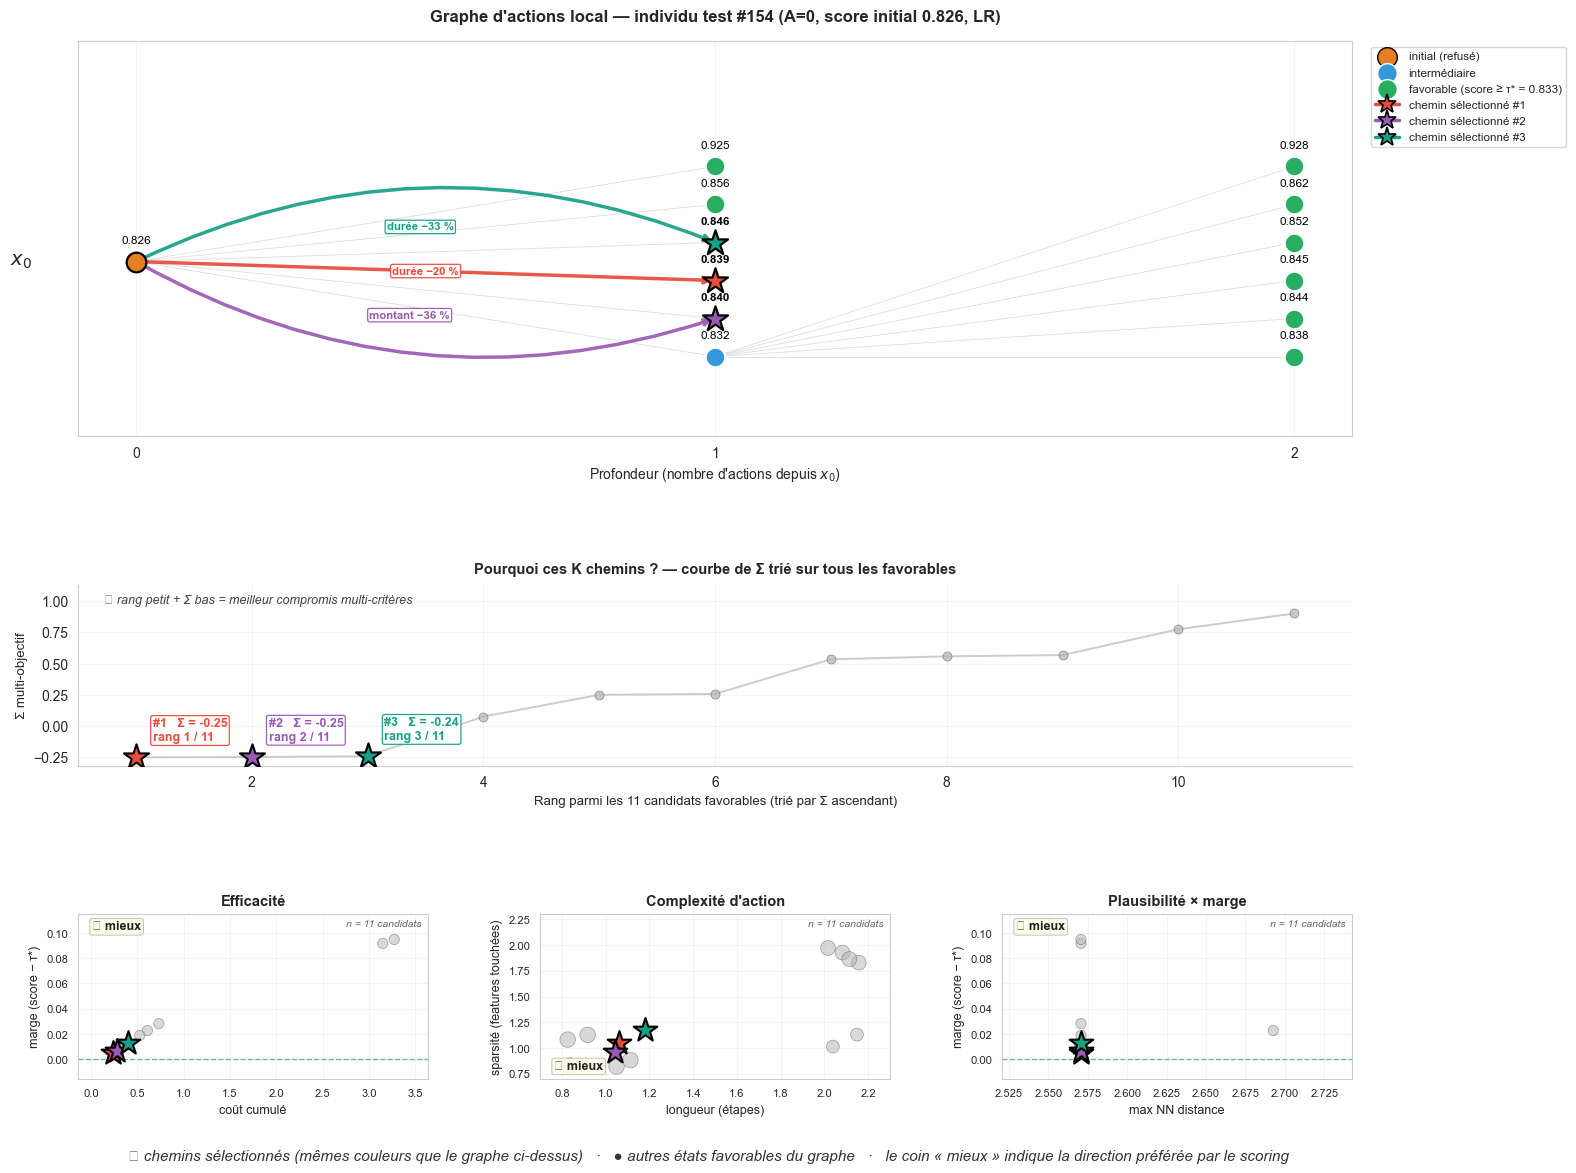

In [7]:
import importlib, pacr_ap
importlib.reload(pacr_ap)
from pacr_ap import plot_action_graph

plot_action_graph(
    res_demo["graph"], res_demo["selected_paths"], rule_global,
    all_paths=res_demo["all_valid_paths"],   # → affiche Σ + rang dans la légende
    title=f"Graphe d'actions local — individu test #{DEMO_IDX} "
           f"(A={int(A_te[DEMO_IDX])}, score initial {p_lr_te[DEMO_IDX]:.3f}, LR)",
)


Le graphe explore toutes les façons dont cet individu peut faire basculer la décision, avec en couleur les trois pistes que la méthode retient. La courbe juste en dessous classe tous les candidats par score multi-objectif Σ pour montrer où se placent ces trois-là, et les trois scatters confirment le compromis axe par axe.

L'individu choisi pour la démo avait un score initial (0.826) qui frôlait déjà le seuil (0.833), ce qui explique pourquoi les chemins retenus sont très courts : une seule action — réduire la durée ou le montant du crédit — suffit à faire basculer la décision. La marge gagnée reste mince et la robustesse bootstrap modeste (~50 %), signe qu'on est vraiment à la limite.

## 5. Audit fairness par groupe

On applique le pipeline aux 30 refusés équilibrés (15 + 15), agrège les
métriques par groupe sensible, calcule les gaps $\Delta_M = M_{A=0} - M_{A=1}$
(jeunes − adultes), et estime leurs **intervalles de confiance bootstrap 95 %**
pour juger de la significativité statistique.


In [8]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import GraphConfig, generate_action_path_recourse_for_dataset

recourse_lr = generate_action_path_recourse_for_dataset(
    X_te_audit, A_te_audit, clf_lr, rule_global, SCHEMA, ACTIONS, X_tr_raw,
    PLAUS_CFG, SCALES,
    graph_cfg=GraphConfig(max_depth=4, beam_width=60, max_nodes=1500),
    boot_models=BOOTSTRAP_LR, feature_cols=FEATURE_COLS,
    model_name="LR", max_individuals=len(X_te_audit),
)
print(f"Coverage LR : {recourse_lr['has_path'].mean():.1%}  "
      f"(jeunes {recourse_lr[recourse_lr.group==0]['has_path'].mean():.0%}  /  "
      f"adultes {recourse_lr[recourse_lr.group==1]['has_path'].mean():.0%})")


Recourse pour 30 refusés (sur 30 au total).
  … 10/30
  … 20/30
  … 30/30
Coverage LR : 66.7%  (jeunes 67%  /  adultes 67%)


In [9]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import fairness_of_recourse_paths

fair_lr, gaps_lr = fairness_of_recourse_paths(recourse_lr)

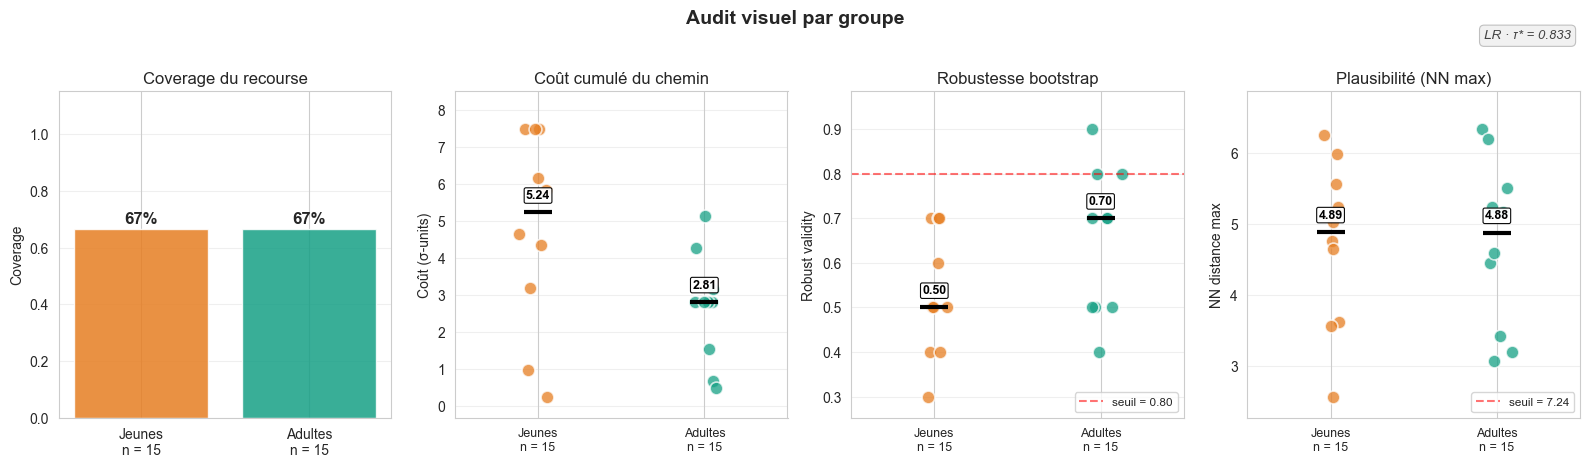

In [10]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import plot_audit_panels

plot_audit_panels(recourse_lr, fair_lr, EPSILON_NN,
                   title_prefix=f"LR · τ* = {TAU_OPT:.3f}")


<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

Quatre vues côte à côte
posent la question sous tous les angles :

<ul style="margin-top:0.8em;">
<li>qui obtient un recourse ;</li>
<li style="margin-top:0.45em;">à quel coût ;</li>
<li style="margin-top:0.45em;">avec quelle robustesse au bruit du modèle ;</li>
<li style="margin-top:0.45em;">et avec quelle plausibilité de l’état final.</li>
</ul>

</div>

<div style="
margin-top:1.5em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Lecture globale.</b>

<p style="margin-top:0.9em;">
La coverage est strictement identique entre les deux groupes :
personne n’est exclu du recourse par construction.
</p>

</div>

$$
67\%
\quad
\text{vs}
\quad
67\%
$$

<div style="
margin-top:1.5em;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.95;
">

La disparité se joue ailleurs.

<p style="margin-top:0.9em;">
Le coût médian des jeunes est presque deux fois plus élevé :
</p>

</div>

$$
5.24
\quad
\text{vs}
\quad
2.81
$$

<div style="
margin-top:1.5em;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.95;
">

et leurs chemins résistent moins bien
au bruit du modèle bootstrap.
</div>

$$
50\%
\quad
\text{vs}
\quad
70\%
$$

<div style="
margin-top:1.5em;
padding:1em 1.15em;
background:rgba(255,255,255,0.03);
border-left:3px solid #8d6cab;
border-radius:6px;
line-height:1.95;
">

Autrement dit :
les jeunes obtiennent autant de recourse,
mais au prix de transformations plus coûteuses
et plus fragiles.

</div>

Quatre vues côte à côte qui posent la question sous tous les angles : qui obtient un recourse, à quel coût, avec quelle robustesse au bruit du modèle, et avec quelle plausibilité de l'état final.

La coverage est strictement égale entre les deux groupes (67 % chacun), donc personne n'est exclu du recourse par construction. La disparité se joue ailleurs : le coût médian des jeunes est **5.24** contre **2.81** chez les adultes (presque le double), et leurs chemins survivent moins bien au bruit du modèle (médiane de robustesse **50 % vs 70 %**).

<div style="font-size:1.35em;font-weight:600;margin-bottom:0.35em;">
5.bis Quelles features sont modifiées par chaque groupe ?
</div>

<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

Le tableau et les panneaux précédents comparent surtout des métriques agrégées :
coverage,
coût,
robustesse
et plausibilité.

<p style="margin-top:0.9em;">
On regarde maintenant quelles features sont effectivement modifiées
par chaque groupe dans leur chemin top-1.
</p>

</div>

<div style="
margin-top:1.5em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Pourquoi c’est important.</b>

<p style="margin-top:0.9em;">
Deux groupes peuvent avoir un coût moyen similaire,
tout en modifiant des variables complètement différentes.
</p>

<p>
Le verdict fairness gagne alors une dimension qualitative :
on ne regarde plus seulement combien coûte le recourse,
mais aussi sur quelles dimensions il repose.
</p>

</div>

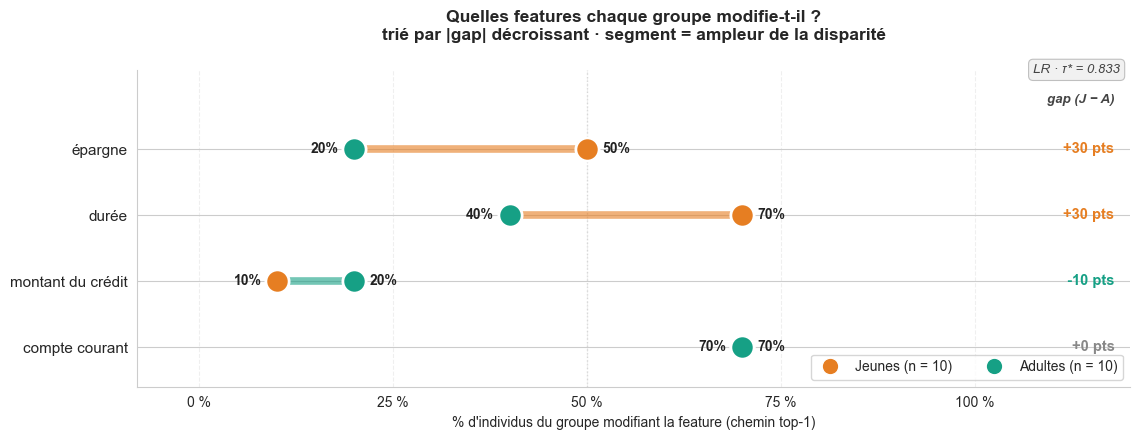

In [11]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import plot_feature_modification_dumbbell

plot_feature_modification_dumbbell(recourse_lr,
                                    title_prefix=f"LR · τ* = {TAU_OPT:.3f}")


<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

Pour chaque feature actionnable,
on lit côte à côte le pourcentage de jeunes
(point orange)
et d’adultes
(point vert)
qui la modifient dans leur chemin top-1.

<p style="margin-top:0.9em;">
La longueur du segment reliant les deux points
donne directement l’écart entre groupes.
</p>

</div>

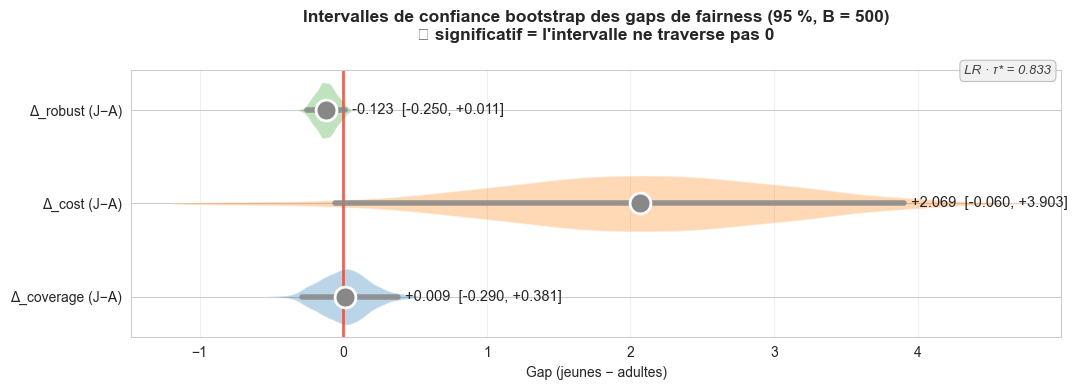

In [12]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import plot_gap_confidence_intervals

_ = plot_gap_confidence_intervals(recourse_lr, n_bootstrap=500, seed=SEED,
                                   title_prefix=f"LR · τ* = {TAU_OPT:.3f}")


<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

Avec seulement 15 jeunes et 15 adultes dans l’audit,
les gaps moyens sont fragiles :
il suffirait de retirer deux individus pour les voir bouger sensiblement.

C’est précisément pour ça qu’on rejoue l’audit 500 fois par bootstrap :
ré-échantillonner les individus avec remise permet d’estimer dans quelle fourchette chaque gap pourrait raisonnablement se trouver,
et donc de distinguer un vrai écart entre groupes d’une simple fluctuation due à la petite taille de l’échantillon.

</div>

<div style="
margin-top:1.5em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Lecture des IC bootstrap.</b>

<p style="margin-top:0.9em;">
Si l’intervalle traverse la ligne rouge :
</p>

</div>

$$
0
$$

<div style="
margin-top:1.4em;
padding-left:1.1em;
border-left:3px solid #666;
line-height:1.95;
">

on ne peut pas conclure à une disparité ;
sinon,
le gap tient malgré le faible effectif.

</div>

<div style="
margin-top:1.8em;
padding:1em 1.15em;
background:rgba(255,255,255,0.03);
border-left:3px solid #8d6cab;
border-radius:6px;
line-height:1.95;
">

<b>Concrètement ici.</b>

<p style="margin-top:0.9em;">
Les trois intervalles traversent zéro,
donc strictement parlant aucun gap n’est significatif au seuil :
</p>

</div>

$$
5\%
$$

<div style="
margin-top:1.5em;
padding-left:1.1em;
border-left:3px solid #8d6cab;
line-height:1.95;
">

Mais :

</div>

$$
\Delta_{\text{cost}}
\qquad
\text{et}
\qquad
\Delta_{\text{robust}}
$$

<div style="
margin-top:1.5em;
padding-left:1.1em;
border-left:3px solid #8d6cab;
line-height:1.95;
">

ne franchissent cette frontière que d’un cheveu
(bornes à −0.06 et +0.01).

Avec un échantillon un peu plus grand,
ils sortiraient très probablement comme significatifs.

</div>

<div style="font-size:1.45em;font-weight:600;margin-bottom:0.35em;">
6. Exploration interactive
</div>

<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

Dashboard cliquable :
un point correspond à un emprunteur refusé.

<p style="margin-top:0.9em;">
Cliquer sur un point révèle son chemin top-1 :
</p>

<ul style="margin-top:0.8em;">
<li>score du modèle à chaque étape </li>
<li style="margin-top:0.45em;">action appliquée </li>
<li style="margin-top:0.45em;">coût cumulé du chemin</li>
</ul>

</div>

In [13]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import GraphConfig, generate_action_path_recourse, action_short_label

import altair as alt
alt.data_transformers.disable_max_rows()

scatter_rows = []
step_rows = []

for _, r in recourse_lr.iterrows():
    test_idx = int(r["test_idx"])
    group_lbl = "Jeune (A=0)" if r["group"] == 0 else "Adulte (A=1)"
    score_orig = float(r["score_orig"])

    if not r["has_path"]:
        scatter_rows.append({
            "test_idx": test_idx, "group": group_lbl,
            "score_orig": score_orig, "final_score": score_orig,
            "cumulative_cost": 0.0, "path_length": 0,
            "robust_validity": 0.0, "has_path": "Aucun chemin trouvé",
            "first_action": "—", "action_sequence": "—",
        })
        step_rows.append({
            "test_idx": test_idx, "group": group_lbl,
            "step": 0, "score": score_orig,
            "action_short": "(initial — aucun chemin)", "action_full": "(aucun chemin trouvé)",
            "cost_cum": 0.0,
        })
        continue

    x0 = X_te_audit.iloc[test_idx]
    res = generate_action_path_recourse(
        x0, clf_lr, rule_global, SCHEMA, ACTIONS, X_tr_raw,
        PLAUS_CFG, SCALES,
        graph_cfg=GraphConfig(max_depth=4, beam_width=60, max_nodes=1500),
        boot_models=BOOTSTRAP_LR, feature_cols=FEATURE_COLS, model_name="LR",
    )
    if not res["selected_paths"]:
        continue
    top = res["selected_paths"][0]

    scatter_rows.append({
        "test_idx": test_idx, "group": group_lbl,
        "score_orig": score_orig,
        "final_score": float(top.final_score),
        "cumulative_cost": float(top.cumulative_cost),
        "path_length": int(top.length),
        "robust_validity": float(top.robust_validity) if top.robust_validity is not None else 0.0,
        "has_path": "Chemin trouvé",
        "first_action": top.first_action or "—",
        "action_sequence": " → ".join(a.name for a in top.actions),
    })

    step_rows.append({
        "test_idx": test_idx, "group": group_lbl,
        "step": 0, "score": score_orig,
        "action_short": "(initial)", "action_full": "(état initial du dossier)",
        "cost_cum": 0.0,
    })
    cum = 0.0
    for t, act in enumerate(top.actions, start=1):
        cum += act.cost_fn(top.states[t-1])
        score_t = float(predict_score(clf_lr, pd.DataFrame([top.states[t]]))[0])
        v_o = top.states[t-1][act.feature]
        v_n = top.states[t][act.feature]
        if isinstance(v_o, float):
            v_o_str = f"{v_o:.0f}"
            v_n_str = f"{v_n:.0f}"
        else:
            v_o_str = str(v_o)
            v_n_str = str(v_n)
        step_rows.append({
            "test_idx": test_idx, "group": group_lbl,
            "step": t, "score": score_t,
            "action_short": action_short_label(act),
            "action_full": f"{action_short_label(act)} — {act.feature}: {v_o_str} → {v_n_str}",
            "cost_cum": cum,
        })

scatter_df = pd.DataFrame(scatter_rows)
step_df = pd.DataFrame(step_rows)
print(f"Scatter : {len(scatter_df)} individus | Step chart : {len(step_df)} étapes")

COLOR_SCALE = alt.Scale(
    domain=["Jeune (A=0)", "Adulte (A=1)"],
    range=["#E67E22", "#16A085"],
)
SHAPE_SCALE = alt.Scale(
    domain=["Chemin trouvé", "Aucun chemin trouvé"],
    range=["circle", "cross"],
)

click_sel = alt.selection_point(fields=["test_idx"], on="click", empty=False, name="picker")

scatter = alt.Chart(scatter_df).mark_point(size=200, filled=True, stroke="white", strokeWidth=1.5).encode(
    x=alt.X("score_orig:Q", title="Score initial f(x₀)",
             scale=alt.Scale(domain=[0, 1])),
    y=alt.Y("final_score:Q", title="Score final après recourse",
             scale=alt.Scale(domain=[0, 1])),
    color=alt.Color(
        "group:N", scale=COLOR_SCALE,
        legend=alt.Legend(
            title="Groupe sensible", orient="right",
            titleFontSize=12, labelFontSize=11,
            symbolSize=220, symbolStrokeWidth=0,
            padding=10, offset=10,
        ),
    ),
    shape=alt.Shape(
        "has_path:N", scale=SHAPE_SCALE,
        legend=alt.Legend(
            title="Statut", orient="right",
            titleFontSize=12, labelFontSize=11,
            symbolSize=180, padding=10, offset=10,
        ),
    ),
    opacity=alt.condition(click_sel, alt.value(1.0), alt.value(0.5)),
    size=alt.condition(click_sel, alt.value(450), alt.value(180)),
    tooltip=[
        alt.Tooltip("test_idx:Q", title="Individu #"),
        alt.Tooltip("group:N", title="Groupe"),
        alt.Tooltip("score_orig:Q", format=".3f", title="Score initial"),
        alt.Tooltip("final_score:Q", format=".3f", title="Score final"),
        alt.Tooltip("path_length:Q", title="Longueur du chemin"),
        alt.Tooltip("cumulative_cost:Q", format=".3f", title="Coût cumulé"),
        alt.Tooltip("robust_validity:Q", format=".0%", title="Robustesse bootstrap"),
        alt.Tooltip("first_action:N", title="Première action"),
        alt.Tooltip("action_sequence:N", title="Séquence d'actions"),
    ],
).add_params(click_sel).properties(
    width=620, height=420,
    title=alt.TitleParams(
        text="Cliquez sur un individu pour voir sa trajectoire de recourse",
        subtitle=[
            "Axe x = score avant recourse | Axe y = score après recourse",
            "Couleur = groupe sensible | Forme = recourse trouvé ou non",
        ],
        fontSize=14, anchor="start",
    ),
)

diag = alt.Chart(pd.DataFrame({"x": [0, 1], "y": [0, 1]})).mark_line(
    color="#888", strokeDash=[3, 3]
).encode(x="x:Q", y="y:Q")

tau_h = alt.Chart(pd.DataFrame({"y": [TAU_OPT]})).mark_rule(
    color="#E74C3C", strokeDash=[6, 4], size=2
).encode(y="y:Q")

tau_v = alt.Chart(pd.DataFrame({"x": [TAU_OPT]})).mark_rule(
    color="#E74C3C", strokeDash=[6, 4], size=2, opacity=0.4
).encode(x="x:Q")

tau_label = alt.Chart(pd.DataFrame({"x": [0.02], "y": [TAU_OPT + 0.025], "text": ["τ* = 0.833"]})).mark_text(
    color="#E74C3C", fontSize=11, fontWeight="bold", align="left",
).encode(x="x:Q", y="y:Q", text="text:N")

scatter_layer = (scatter + diag + tau_h + tau_v + tau_label).interactive()

step_base = alt.Chart(step_df).transform_filter(click_sel)

step_line = step_base.mark_line(
    color="#9B59B6", strokeWidth=4, point=alt.OverlayMarkDef(
        size=220, filled=True, stroke="white", strokeWidth=2,
    )
).encode(
    x=alt.X("step:O", title="Étape du chemin"),
    y=alt.Y("score:Q", title="Score du modèle", scale=alt.Scale(domain=[0, 1])),
    color=alt.Color("group:N", scale=COLOR_SCALE, legend=None),
    tooltip=[
        alt.Tooltip("step:O", title="Étape"),
        alt.Tooltip("score:Q", format=".3f", title="Score"),
        alt.Tooltip("action_full:N", title="Action"),
        alt.Tooltip("cost_cum:Q", format=".3f", title="Coût cumulé"),
    ],
)

step_labels = step_base.mark_text(
    align="left", dx=12, dy=-12, fontSize=10.5, color="#1F2A36",
).encode(
    x="step:O", y="score:Q", text="action_short:N",
)

step_tau = alt.Chart(pd.DataFrame({"y": [TAU_OPT]})).mark_rule(
    color="#E74C3C", strokeDash=[6, 4], size=2,
).encode(y="y:Q")

step_tau_label = alt.Chart(pd.DataFrame({
    "x": [0], "y": [TAU_OPT + 0.03], "text": ["τ* = 0.833 (seuil cost-optimal)"]
})).mark_text(color="#E74C3C", fontSize=11, fontWeight="bold", align="left").encode(
    x="x:O", y="y:Q", text="text:N",
)

step_chart = (step_line + step_labels + step_tau + step_tau_label).properties(
    width=620, height=320,
    title=alt.TitleParams(
        text="Progression du score le long du chemin sélectionné",
        subtitle="Chaque point = un état | étiquette = action appliquée pour y arriver",
        fontSize=13, anchor="start",
    ),
)

cost_chart = step_base.mark_area(
    color="#5AAC68", opacity=0.6, line={"strokeWidth": 3},
).encode(
    x=alt.X("step:O", title="Étape"),
    y=alt.Y("cost_cum:Q", title="Coût cumulé (σ-units)"),
    tooltip=[
        alt.Tooltip("step:O", title="Étape"),
        alt.Tooltip("cost_cum:Q", format=".3f", title="Coût cumulé"),
        alt.Tooltip("action_full:N", title="Action"),
    ],
).properties(
    width=620, height=200,
    title=alt.TitleParams(text="Coût cumulé du chemin",
                          subtitle="Sommé en multiples d'écart-type empirique",
                          fontSize=12, anchor="start"),
)

dashboard = scatter_layer & step_chart & cost_chart
dashboard


ModuleNotFoundError: No module named 'altair'

Tableau de bord interactif : chaque point représente un refusé, placé selon son score initial (axe x) et son score après recourse (axe y). Un clic sur un point fait apparaître en bas la trajectoire complète du chemin recommandé pour cet individu.

## 7. Robustesse du verdict au schéma d'actions

Le **schéma d'actionnabilité** (quelles features sont mutables) est le seul
choix politique non-empirique de la méthode. On vérifie que le verdict de
fairness ne dépend pas arbitrairement de ce choix, en rejouant l'audit sous
trois variants (`conservateur`, `modéré`, `permissif`). Un verdict défendable
garde le **même signe** sur les trois.


In [ ]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import GraphConfig, load_schema_from_yaml, mine_actions_from_data, generate_action_path_recourse_for_dataset, fairness_of_recourse_paths

SENSITIVITY_VARIANTS = ["conservateur", "modere", "permissif"]

sensitivity_rows = []
for variant in SENSITIVITY_VARIANTS:
    schema_v, orders_v, _ = load_schema_from_yaml(POLICY_PATH, variant_name=variant)
    actions_v, _report_v = mine_actions_from_data(
        X_tr_raw, y_tr, schema_v, orders_v, EMP_BOUNDS, SCALES,
        k_neighbors=10, min_support=30,
    )
    print(f"  variant {variant:>13s} : {len(actions_v)} actions minées, {sum(1 for s in schema_v.values() if s.mutable)} features mutables")
    recourse_v = generate_action_path_recourse_for_dataset(
        X_te_audit, A_te_audit, clf_lr, rule_global, schema_v, actions_v, X_tr_raw,
        PLAUS_CFG, SCALES,
        graph_cfg=GraphConfig(max_depth=4, beam_width=60, max_nodes=1500),
        boot_models=BOOTSTRAP_LR, feature_cols=FEATURE_COLS,
        model_name="LR", max_individuals=len(X_te_audit),
    )
    fair_v, gaps_v = fairness_of_recourse_paths(recourse_v)
    sensitivity_rows.append({
        "variant": variant, "n_actions": len(actions_v),
        "n_J": int(fair_v.iloc[0]["n_refused"]), "n_A": int(fair_v.iloc[1]["n_refused"]),
        "cov_J": fair_v.iloc[0]["coverage"], "cov_A": fair_v.iloc[1]["coverage"],
        "cost_J": fair_v.iloc[0]["mean_cost"], "cost_A": fair_v.iloc[1]["mean_cost"],
        "robust_J": fair_v.iloc[0]["mean_robust"], "robust_A": fair_v.iloc[1]["mean_robust"],
        "Δ_cov": float(gaps_v.iloc[0, 0]) if len(gaps_v) else np.nan,
        "Δ_cost": float(gaps_v.iloc[0, 2]) if len(gaps_v) else np.nan,
        "Δ_robust": float(gaps_v.iloc[0, 6]) if len(gaps_v) else np.nan,
    })

sens_df = pd.DataFrame(sensitivity_rows)


In [ ]:
import importlib, pacr_ap; importlib.reload(pacr_ap)
from pacr_ap import plot_sensitivity_gaps

plot_sensitivity_gaps(
    sens_df,
    title="Sensibilité du verdict au schéma d'actions",
    context=f"LR · τ* = {TAU_OPT:.3f}",
)


<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.95;
">

On rejoue ensuite l’audit sous chacun des trois variants du schéma
d’actionnabilité :

<ul style="margin-top:0.8em;">
<li><code>conservateur</code></li>
<li style="margin-top:0.45em;"><code>modéré</code></li>
<li style="margin-top:0.45em;"><code>permissif</code></li>
</ul>

<p style="margin-top:0.9em;">
et on compare les trois gaps de fairness obtenus :
une barre par couple :
</p>

</div>

$$
(\text{métrique},\ \text{variant})
$$

<div style="
margin-top:1.5em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

<b>Lecture du verdict.</b>

<p style="margin-top:0.9em;">
Pour chaque métrique :
</p>

</div>

$$
\Delta_{\text{coverage}},
\qquad
\Delta_{\text{cost}},
\qquad
\Delta_{\text{robust}}
$$

<div style="
margin-top:1.2em;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.95;
">

<b>Cas 1 — signe identique sur les 3 variants</b>

<p style="margin-top:0.9em;">
Le verdict est considéré comme robuste au choix de politique :
le gap entre jeunes et adultes persiste
quel que soit le schéma d’actionnabilité retenu.
</p>

<p>
Autrement dit :
la disparité observée n’est pas un artefact
du périmètre d’actions autorisé.
</p>

</div>

<div style="
margin-top:1.5em;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.95;
">

<b>Cas 2 — inversion du signe</b>

<p style="margin-top:0.9em;">
Le verdict dépend alors du schéma choisi.
</p>

<p>
La conclusion fairness change selon ce qu’on autorise
ou interdit comme actions.
</p>

<p>
Dans ce cas,
le choix du schéma d’actionnabilité devient lui-même
une hypothèse normative forte
qui doit être explicitement justifiée.
</p>

</div>

<div style="
margin-top:1.8em;
padding:1em 1.15em;
background:rgba(255,255,255,0.03);
border-left:3px solid #8d6cab;
border-radius:6px;
line-height:1.95;
">

<b>Résultat observé ici.</b>

<p style="margin-top:0.9em;">
Sur les trois variants :
</p>

<ul style="margin-top:0.8em;">
<li><code>conservateur</code></li>
<li style="margin-top:0.45em;"><code>modéré</code></li>
<li style="margin-top:0.45em;"><code>permissif</code></li>
</ul>

<p style="margin-top:0.9em;">
le signe du gap de coût reste systématiquement positif :
</p>

</div>

$$
\Delta_{\text{cost}} > 0
$$

<div style="
margin-top:1.5em;
padding-left:1.1em;
border-left:3px solid #8d6cab;
line-height:1.95;
">

<p>
Les jeunes paient donc systématiquement plus cher
leur recourse que les adultes,
indépendamment du périmètre d’actions autorisé.
</p>

<p>
Le verdict de disparité est donc stable
au stress-test de politique.
</p>

</div>

<hr style="margin:3em 0;border:none;border-top:1px solid rgba(255,255,255,0.10);">

<div style="font-size:1.45em;font-weight:600;margin-bottom:0.35em;">
8. Conclusion et limites
</div>

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #7a8fb8;line-height:1.95;">
<b>Ce qu’on observe</b>

<p style="margin-top:0.9em;">
Les résultats bootstrap ne permettent pas de conclure à un effet strictement
significatif au seuil 5 % :
les trois intervalles de confiance traversent zéro.
</p>

<p>
Mais la lecture par cohérence des signes donne une information plus qualitative :
le coût du recourse est systématiquement plus élevé pour les jeunes,
et la robustesse est systématiquement plus faible.
</p>
</div>

| Gap | Médiane bootstrap | IC 95 % | Signes sur les 3 variants |
|---|---:|---:|---|
| Δ_coverage | +0.01 | [−0.29, +0.38] | 0 / +0 / 0 |
| Δ_cost | **+2.07** | [−0.06, +3.90] | +2.14 / +1.36 / +1.34 |
| Δ_robust | **−0.12** | [−0.25, +0.01] | −0.12 / −0.16 / −0.06 |

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #b88a4a;line-height:1.95;">
<b>Lecture des résultats</b>

<p style="margin-top:0.9em;">
Si l’on s’en tient uniquement aux intervalles de confiance bootstrap,
aucun gap n’est strictement significatif.
</p>

<p>
Cela est attendu :
l’audit repose sur un petit échantillon équilibré,
avec seulement 15 jeunes et 15 adultes parmi les refusés.
</p>
</div>

$$
15\ \text{jeunes}
\quad+\quad
15\ \text{adultes}
$$

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #b88a4a;line-height:1.95;">
<p>
En revanche,
le stress-test sur les trois variantes du schéma d’actionnabilité
montre une tendance stable :
</p>

<ul style="margin-top:0.8em;">
<li>les jeunes paient systématiquement plus cher leur recourse ;</li>
<li style="margin-top:0.45em;">leurs chemins sont systématiquement moins robustes ;</li>
<li style="margin-top:0.45em;">la coverage ne montre pas d’effet net.</li>
</ul>
</div>

$$
\Delta_{\text{cost}} > 0
$$

$$
\Delta_{\text{robust}} < 0
$$

<div style="margin-top:1.5em;padding:1em 1.15em;background:rgba(255,255,255,0.035);border-left:3px solid #666;border-radius:6px;line-height:1.95;">
<b>Bilan honnête.</b>

On observe une tendance solide sur deux axes :
coût et robustesse.

<p style="margin-top:0.9em;">
Mais ce n’est pas un fait certain au sens statistique strict.
Le dataset est trop petit pour trancher sans hésitation,
et ces conclusions devraient être testées sur un échantillon plus large
avant d’être formulées comme une affirmation forte.
</p>
</div>

<hr style="margin:3em 0;border:none;border-top:1px solid rgba(255,255,255,0.10);">

<div style="font-size:1.25em;font-weight:600;margin:2em 0 1.2em 0;">
Ce que cette méthode ne fait pas
</div>

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #7a8fb8;line-height:1.95;">
<b>1. Le recourse reste prédictif, pas causal</b>

<p style="margin-top:0.9em;">
PACR-AP explique comment changer la décision du modèle,
mais pas comment réduire le vrai risque de défaut.
</p>

<p>
Réduire le montant demandé peut faire baisser le score du modèle,
sans rendre causalement l’individu meilleur emprunteur.
</p>
</div>

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #7a8fb8;line-height:1.95;">
<b>2. Le dataset est petit</b>

<p style="margin-top:0.9em;">
German Credit contient 1000 individus,
mais seulement une petite fraction de jeunes refusés
sous le seuil cost-optimal élevé.
</p>

<p>
Même avec un audit équilibré,
les intervalles de confiance bootstrap restent larges.
</p>
</div>

$$
n = 1000
$$

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #7a8fb8;line-height:1.95;">
<b>3. Le schéma d’actionnabilité reste subjectif</b>

<p style="margin-top:0.9em;">
Définir ce qu’un emprunteur peut raisonnablement modifier
est un choix éthique et métier.
</p>

<p>
Le stress-test montre que le verdict tient sur trois variantes raisonnables,
mais un schéma très différent pourrait conduire à une autre conclusion.
</p>
</div>

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #7a8fb8;line-height:1.95;">
<b>4. Le mining est co-adapté au modèle audité</b>

<p style="margin-top:0.9em;">
Les magnitudes d’actions sont apprises à partir de transitions
refusé → favorable du training.
</p>

<p>
Elles sont donc liées au modèle et au seuil utilisés.
Pour auditer un autre modèle,
il faudrait re-miner les magnitudes depuis zéro.
</p>
</div>

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #7a8fb8;line-height:1.95;">
<b>5. La robustesse est intra-modèle</b>

<p style="margin-top:0.9em;">
Le bootstrap teste la sensibilité au rééchantillonnage du training set,
pas la sensibilité au choix de la classe de modèle.
</p>

<p>
Un modèle linéaire et un modèle non linéaire pourraient proposer
des chemins différents pour le même individu.
</p>
</div>

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #7a8fb8;line-height:1.95;">
<b>6. Le temps n’est pas modélisé</b>

<p style="margin-top:0.9em;">
Les actions sont traitées comme des transitions instantanées.
</p>

<p>
La méthode ne capture pas encore la dynamique réelle d’un parcours :
faire une première action,
attendre plusieurs mois,
puis réaliser une seconde action.
</p>
</div>

<div style="margin-top:1.5em;padding:1em 1.15em;background:rgba(255,255,255,0.035);border-left:3px solid #666;border-radius:6px;line-height:1.95;">
<b>Limite pratique.</b>

Cette absence de temporalité est importante
si l’on veut transformer le recourse
en véritable feuille de route client.
</div>

<hr style="margin:3em 0;border:none;border-top:1px solid rgba(255,255,255,0.10);">

<div style="font-size:1.25em;font-weight:600;margin:2em 0 1.2em 0;">
Où aller ensuite
</div>

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #8d6cab;line-height:1.95;">
<b>1. Plausibilité plus riche</b>

<p style="margin-top:0.9em;">
Remplacer ou compléter le filtre NN + LOF
par des méthodes à variété latente,
comme C-CHVAE ou REVISE.
</p>

<p>
Cela permettrait de mieux capturer
des distributions complexes de profils.
</p>
</div>

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #8d6cab;line-height:1.95;">
<b>2. Recourse véritablement causal</b>

<p style="margin-top:0.9em;">
Construire un modèle causal structurel explicite
permettrait de distinguer les changements qui modifient la décision du modèle
de ceux qui modifient réellement le risque.
</p>

<p>
C’est plus exigeant en hypothèses,
mais c’est la réponse directe à la limite causale.
</p>
</div>

<div style="margin:1.5em 0;padding-left:1.1em;border-left:3px solid #8d6cab;line-height:1.95;">
<b>3. Recourse multi-modèle</b>

<p style="margin-top:0.9em;">
Une extension naturelle serait de ne retenir que les chemins
qui font basculer plusieurs modèles à la fois.
</p>
</div>

$$
\text{LR}
\quad
\text{XGBoost}
\quad
\text{RandomForest}
$$

<div style="margin-top:1.5em;padding:1em 1.15em;background:rgba(255,255,255,0.035);border-left:3px solid #666;border-radius:6px;line-height:1.95;">
<b>Idée finale.</b>

Un recourse consensus,
valide pour plusieurs classes de modèles,
serait plus défendable qu’un chemin
qui ne tient que sur un seul classifieur.
</div>

In [ ]:
import importlib, pacr_ap; importlib.reload(pacr_ap)

print(f"Refusés vus       : {MINING_REPORT['n_refused']}")
print(f"Favorables vus    : {MINING_REPORT['n_favorable']}")
print(f"k voisins / refusé: {MINING_REPORT['k_neighbors']}")
print(f"Min support       : {MINING_REPORT['min_support']}")
print(f"Total paires      : {MINING_REPORT['n_pairs_total']}")
print()
for feat, rep in MINING_REPORT['per_feature'].items():
    if 'skip' in rep:
        print(f"  {feat:<22s} : SKIPPED ({rep['skip']})")
        continue
    if not rep['actions_mined']:
        print(f"  {feat:<22s} : aucune action minée (filtres trop stricts)")
        continue
    print(f"  {feat:<22s} ({rep['type']}, {rep['direction']})")
    print(f"    └─ {rep['n_observations']} transitions observées")
    if rep['type'] == 'continuous':
        s = rep['observed_pct_summary']
        print(f"    └─ percentiles observés : p25={s['p25']*100:.0f}%  "
              f"p50={s['p50']*100:.0f}%  p75={s['p75']*100:.0f}%")
        vals = ", ".join(f"{a['value']*100:.0f}%" for a in rep['actions_mined'])
        print(f"    └─ magnitudes retenues  : [{vals}]")
    elif rep['type'] == 'ordinal':
        steps = ", ".join(f"step={a['value']:+d} (n={a['count']})"
                          for a in rep['actions_mined'])
        print(f"    └─ steps retenus        : {steps}")
    else:
        targets = ", ".join(f"{a['value']!r} (n={a['count']})"
                            for a in rep['actions_mined'])
        print(f"    └─ cibles retenues      : {targets}")
    print()
